<a href="https://colab.research.google.com/github/sanjana62000/word-embeddings-/blob/main/word_embeddings.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Epoch 10, Loss: 1382.7492
Epoch 20, Loss: 1332.4124
Epoch 30, Loss: 1315.3246
Epoch 40, Loss: 1294.3495
Epoch 50, Loss: 1291.5100
Epoch 60, Loss: 1285.4171
Epoch 70, Loss: 1272.2561
Epoch 80, Loss: 1272.2487
Epoch 90, Loss: 1270.3391
Epoch 100, Loss: 1262.6259
Epoch 110, Loss: 1258.3232
Epoch 120, Loss: 1254.8540
Epoch 130, Loss: 1258.1348
Epoch 140, Loss: 1248.3659
Epoch 150, Loss: 1254.6390
Epoch 160, Loss: 1250.9587
Epoch 170, Loss: 1254.3593
Epoch 180, Loss: 1246.2885
Epoch 190, Loss: 1249.1682
Epoch 200, Loss: 1241.3075
Epoch 210, Loss: 1250.1626
Epoch 220, Loss: 1251.0583
Epoch 230, Loss: 1242.8829
Epoch 240, Loss: 1241.4970
Epoch 250, Loss: 1237.4159
Epoch 260, Loss: 1244.9775
Epoch 270, Loss: 1240.6909
Epoch 280, Loss: 1244.9758
Epoch 290, Loss: 1240.6522
Epoch 300, Loss: 1240.3400
Epoch 310, Loss: 1244.3342
Epoch 320, Loss: 1235.4758
Epoch 330, Loss: 1235.4670
Epoch 340, Loss: 1238.8255
Epoch 350, Loss: 1232.5180
Epoch 360, Loss: 1242.9358
Epoch 370, Loss: 1242.3506
Epoch 380,

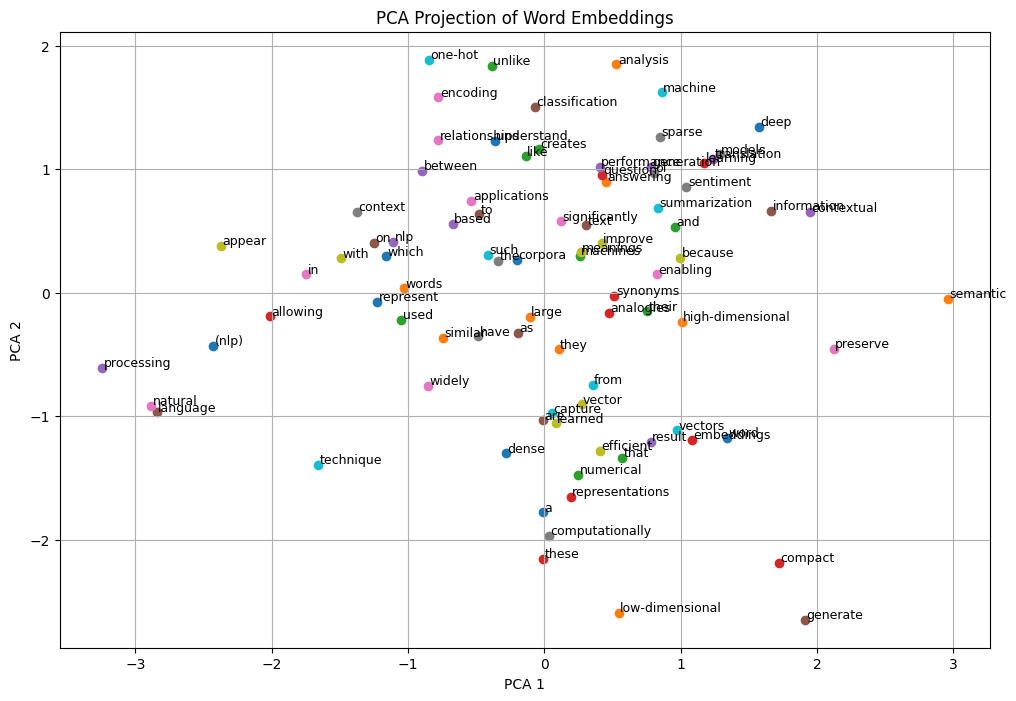

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from collections import Counter
import random
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import os

# Step 1: Text Corpus
corpus = """
Word Embeddings are a technique in Natural Language Processing (NLP) used to represent words as dense numerical vectors that capture their meanings and relationships.
Unlike one-hot encoding, which creates sparse and high-dimensional vectors, word embeddings generate compact, low-dimensional representations that are computationally efficient.
These vectors are learned from large text corpora based on the context in which words appear, allowing words with similar meanings to have similar vector representations.
As a result, word embeddings preserve semantic and contextual information, enabling machines to understand relationships between words such as synonyms and analogies.
They are widely used in NLP applications like sentiment analysis, machine translation, text classification, question answering, text summarization, and text generation because they significantly improve the performance of machine learning and deep learning models.
"""

# Preprocess the data
def preprocess(text):
    return text.lower().replace('.', '').replace(',', '').split()

tokens = preprocess(corpus)
vocab = set(tokens)
word2idx = {w: idx for idx, w in enumerate(vocab)}
idx2word = {idx: w for w, idx in word2idx.items()}
vocab_size = len(vocab)

# Step 3: Generate Skip-Gram Pairs
def generate_skip_grams(tokens, window_size=2):
    pairs = []
    for idx, center in enumerate(tokens):
        for w in range(-window_size, window_size + 1):
            context_idx = idx + w
            if w == 0 or context_idx < 0 or context_idx >= len(tokens):
                continue
            pairs.append((center, tokens[context_idx]))
    return pairs

skip_grams = generate_skip_grams(tokens)
data = [(word2idx[c], word2idx[t]) for c, t in skip_grams]

# Step 4: Define Word2Vec Model
class Word2Vec(nn.Module):
    def __init__(self, vocab_size, embed_dim):
        super(Word2Vec, self).__init__()
        self.embeddings = nn.Embedding(vocab_size, embed_dim)
        self.output = nn.Linear(embed_dim, vocab_size)

    def forward(self, center_words):
        embeds = self.embeddings(center_words)
        out = self.output(embeds)
        return out

#  Step 5: Training
embed_dim = 20
model = Word2Vec(vocab_size, embed_dim)
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

# Training loop
for epoch in range(1000):
    total_loss = 0
    random.shuffle(data)
    for center, context in data:
        center_tensor = torch.tensor([center], dtype=torch.long)
        context_tensor = torch.tensor([context], dtype=torch.long)

        optimizer.zero_grad()
        output = model(center_tensor)
        loss = loss_fn(output, context_tensor)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")

# Step 6: Save Model
os.makedirs("model", exist_ok=True)
torch.save(model.state_dict(), "model/word2vec.pth")
print("Model saved at model/word2vec.pth")

# Step 7: Visualize Embeddings with PCA
embeddings = model.embeddings.weight.data.numpy()
print(embeddings)
# Reduce dimensionality with PCA
pca = PCA(n_components=2)
reduced_embeddings = pca.fit_transform(embeddings)

# Plot
plt.figure(figsize=(12, 8))
for i, label in enumerate(vocab):
    x, y = reduced_embeddings[i]
    plt.scatter(x, y)
    plt.annotate(label, (x + 0.01, y + 0.01), fontsize=9)
plt.title("PCA Projection of Word Embeddings")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.grid(True)
plt.show()

In [3]:
print(word2idx)

{'corpora': 0, 'answering': 1, 'like': 2, 'synonyms': 3, 'based': 4, 'language': 5, 'natural': 6, 'have': 7, 'because': 8, 'capture': 9, 'which': 10, 'low-dimensional': 11, 'that': 12, 'representations': 13, 'processing': 14, 'text': 15, 'applications': 16, 'of': 17, 'efficient': 18, 'such': 19, 'word': 20, 'analysis': 21, 'creates': 22, 'learning': 23, 'between': 24, 'generate': 25, 'encoding': 26, 'the': 27, 'appear': 28, 'machine': 29, 'a': 30, 'they': 31, 'machines': 32, 'question': 33, 'result': 34, 'on': 35, 'enabling': 36, 'sentiment': 37, 'learned': 38, 'technique': 39, 'understand': 40, 'similar': 41, 'numerical': 42, 'allowing': 43, 'translation': 44, 'information': 45, 'widely': 46, 'context': 47, 'meanings': 48, 'summarization': 49, 'deep': 50, 'large': 51, 'and': 52, 'compact': 53, 'contextual': 54, 'as': 55, 'in': 56, 'sparse': 57, 'vector': 58, 'vectors': 59, 'dense': 60, 'semantic': 61, 'unlike': 62, 'these': 63, 'performance': 64, 'classification': 65, 'significantly':

Gensim

In [4]:
! pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 61.9 MB/s eta 0:00:00


In [5]:
# training using Gensim Word2Vec
from gensim.test.utils import common_texts
from gensim.models import Word2Vec

In [6]:
# define training data
sentences = [['this', 'is', 'the', 'first', 'sentence', 'for', 'word2vec'],
			['this', 'is', 'the', 'second', 'sentence'],
			['yet', 'another', 'sentence'],
			['one', 'more', 'sentence'],
			['and', 'the', 'final', 'sentence']]
# train model
model = Word2Vec(sentences, min_count=1)
# summarize the loaded model
print(model)
# summarize vocabulary
words = list(model.wv.key_to_index)
print(words)
# access vector for one word
print(model.wv.get_vector("final", norm=True))
# save model
model.save('model.bin')
# load model
new_model = Word2Vec.load('model.bin')
print(new_model)

Word2Vec<vocab=14, vector_size=100, alpha=0.025>
['sentence', 'the', 'is', 'this', 'final', 'and', 'more', 'one', 'another', 'yet', 'second', 'word2vec', 'for', 'first']
[-0.12348268  0.02146596 -0.12413479 -0.03882489  0.06433234  0.10089484
  0.02072483  0.03637069 -0.07109694  0.12497572 -0.10909214  0.08038233
 -0.14217988  0.03522454 -0.08608747 -0.07347175 -0.05377573  0.09781746
  0.10029424 -0.0860459   0.01337621 -0.14695044  0.13508527  0.16012225
 -0.04743371  0.01384137  0.01291475  0.09475031 -0.14885831  0.01010926
  0.11881956  0.03859962  0.01945339 -0.1612442   0.14671847 -0.10834985
 -0.05175873  0.06043161 -0.01336405  0.02441094  0.0308229  -0.11811865
 -0.1682089   0.1563739   0.107207   -0.11957207  0.05886963  0.00356426
  0.08222497 -0.12315279  0.06965373  0.07519705  0.17223142 -0.07738174
 -0.02402993 -0.12656683 -0.16774218 -0.15706012 -0.01769047 -0.11248662
  0.08388516 -0.10661842  0.04357405  0.01279002 -0.05867368 -0.01693751
  0.17260772  0.1581953  -0

In [8]:
import gensim.downloader
# Show all available models in gensim-data
print(list(gensim.downloader.info()['models'].keys()))

# Download the "glove-twitter-50" embeddings
glove_vectors = gensim.downloader.load('glove-twitter-50')

# Use the downloaded vectors as usual:
glove_vectors.most_similar('python', topn=10)

['fasttext-wiki-news-subwords-300', 'conceptnet-numberbatch-17-06-300', 'word2vec-ruscorpora-300', 'word2vec-google-news-300', 'glove-wiki-gigaword-50', 'glove-wiki-gigaword-100', 'glove-wiki-gigaword-200', 'glove-wiki-gigaword-300', 'glove-twitter-25', 'glove-twitter-50', 'glove-twitter-100', 'glove-twitter-200', '__testing_word2vec-matrix-synopsis']
[==================================================] 100.0% 199.5/199.5MB downloaded


[('magnetic', 0.7398850321769714),
 ('javascript', 0.7352427840232849),
 ('perl', 0.7323213815689087),
 ('illustrator', 0.7288448810577393),
 ('adobe', 0.7275927066802979),
 ('pinball', 0.7256501317024231),
 ('rails', 0.7217376828193665),
 ('robotic', 0.7151577472686768),
 ('gnome', 0.7139864563941956),
 ('hybrid', 0.7080456018447876)]

In [9]:
glove_vectors.get_vector("google")

array([ 1.0519  ,  0.60461 , -1.0756  ,  0.45193 , -0.064418,  0.17597 ,
        0.30264 , -0.70928 ,  0.73155 ,  0.13197 ,  0.29944 ,  0.20064 ,
       -2.927   ,  0.099191, -0.62304 , -0.12481 ,  0.36649 ,  0.77723 ,
        1.0052  , -0.49404 , -0.35774 , -0.72642 , -0.38302 , -0.69603 ,
       -0.86929 , -1.1595  ,  0.30699 , -0.043333,  0.13824 ,  0.063458,
       -0.32907 , -0.27476 , -0.60251 , -1.1986  ,  1.0312  ,  0.23446 ,
        0.56289 , -0.30764 , -0.56176 , -0.64596 , -1.3328  ,  0.22566 ,
       -0.93916 ,  0.48007 ,  0.57339 , -0.42139 , -0.78537 ,  0.20075 ,
       -1.1138  , -0.026187], dtype=float32)

In [10]:
glove_vectors.most_similar("apple")

[('microsoft', 0.8666837811470032),
 ('google', 0.8337891697883606),
 ('samsung', 0.8189260363578796),
 ('nokia', 0.8133970499038696),
 ('ipad', 0.806841254234314),
 ('iphone', 0.806834876537323),
 ('galaxy', 0.8041617274284363),
 ('blackberry', 0.7953041791915894),
 ('android', 0.7887364625930786),
 ('smartphone', 0.788325846195221)]

In [11]:
glove_vectors.most_similar('computer', topn=5)

[('cell', 0.8157469630241394),
 ('laptop', 0.811658501625061),
 ('desktop', 0.8046691417694092),
 ('phone', 0.8026933670043945),
 ('computers', 0.7978081703186035)]

In [12]:
tokens = list(glove_vectors.key_to_index)
print(tokens[:100])

['<user>', '.', ':', 'rt', ',', '<repeat>', '<hashtag>', '<number>', '<url>', '!', 'i', 'a', '"', 'the', '?', 'you', 'to', '(', '<allcaps>', '<elong>', ')', 'me', 'de', '<smile>', '！', 'que', 'and', '。', '-', 'my', 'no', '、', 'is', 'it', '…', 'in', 'n', 'for', '/', 'of', 'la', "'s", '*', 'do', "n't", 'that', 'on', 'y', "'", 'e', 'o', 'u', 'en', 'this', 'el', 'so', 'be', "'m", 'with', 'just', '>', 'your', '^', 'like', 'have', 'te', 'at', '？', 'love', 'se', 'are', '<', 'm', 'r', 'if', 'all', 'b', '・', 'not', 'but', 'we', 'es', 'ya', '&', 'follow', 'up', 'what', 'get', 'lol', 'un', '♥', 'lo', 'when', 'was', '“', '”', 'one', 'por', 'si', 'out']


In [13]:
len(glove_vectors)

1193514

In [14]:
glove_vectors.most_similar('dog')

[('cat', 0.9429584741592407),
 ('dogs', 0.8918037414550781),
 ('puppy', 0.8790459632873535),
 ('pet', 0.8722651600837708),
 ('bear', 0.8573998212814331),
 ('cats', 0.851166307926178),
 ('kid', 0.8403224349021912),
 ('horse', 0.8380487561225891),
 ('monkey', 0.8318661451339722),
 ('pig', 0.8194695115089417)]

In [15]:
glove_vectors.most_similar('good')

[('well', 0.9244242310523987),
 ('great', 0.9227153062820435),
 ('too', 0.9198312163352966),
 ('nice', 0.9169182181358337),
 ('better', 0.9147132039070129),
 ('day', 0.9091806411743164),
 ('this', 0.9072596430778503),
 ('it', 0.9027184247970581),
 ('night', 0.8996105790138245),
 ('way', 0.8987061381340027)]

In [16]:

glove_vectors = gensim.downloader.load('glove-wiki-gigaword-300')

# Use the downloaded vectors as usual:
glove_vectors.most_similar('dog')

[==================================================] 100.0% 376.1/376.1MB downloaded


[('dogs', 0.7888557314872742),
 ('cat', 0.6816746592521667),
 ('pet', 0.6291598081588745),
 ('puppy', 0.593606173992157),
 ('hound', 0.5468214750289917),
 ('horse', 0.5369751453399658),
 ('animal', 0.5316445827484131),
 ('cats', 0.5080744028091431),
 ('canine', 0.5038436055183411),
 ('pets', 0.5019966959953308)]

In [17]:
glove_vectors.get_vector("dog")

array([-1.1043e-01,  8.1217e-01,  7.3668e-02,  1.9023e-01, -5.2888e-02,
        6.1468e-02,  1.6076e-01,  4.1302e-01, -3.0199e-01, -9.0827e-01,
        2.7504e-01, -3.1890e-02, -2.8842e-01,  2.3447e-01,  4.7679e-01,
        5.0124e-01,  2.9371e-01,  2.7029e-01,  5.4745e-02,  9.8038e-02,
        5.7116e-01,  3.6755e-01,  4.0734e-02,  3.4347e-01, -1.8256e-01,
       -2.8935e-01,  2.3826e-02, -1.9401e-01,  2.4444e-01,  1.3407e-01,
       -1.6494e-01, -2.6983e-01, -2.6234e-01, -2.1779e-01, -8.7528e-01,
        7.3822e-01, -8.7931e-02, -1.0876e-02, -2.6540e-01,  3.4668e-01,
       -5.5814e-01,  1.7591e-01,  1.6926e-01, -1.5725e-01, -5.0430e-01,
       -2.0100e-01,  6.6701e-01, -3.2518e-02,  4.5012e-02,  6.5675e-02,
       -1.6061e-01, -7.3363e-01,  2.4642e-01,  3.4325e-01,  2.1899e-01,
        4.8646e-02, -5.9987e-01, -5.8153e-02, -5.1694e-02, -5.7846e-01,
        3.0000e-01,  3.5078e-01,  4.6646e-01, -7.5309e-03,  1.0455e-01,
       -5.1016e-01, -5.5987e-02, -1.0295e-01, -2.6476e-01, -4.12

In [18]:
glove_vectors.get_vector("cat")

array([-0.29353  ,  0.33247  , -0.047372 , -0.12247  ,  0.071956 ,
       -0.23408  , -0.06238  , -0.0037192, -0.39462  , -0.69411  ,
        0.36731  , -0.12141  , -0.044485 , -0.15268  ,  0.34864  ,
        0.22926  ,  0.54361  ,  0.25215  ,  0.097972 , -0.087305 ,
        0.87058  , -0.12211  , -0.079825 ,  0.28712  , -0.68563  ,
       -0.27265  ,  0.22056  , -0.75752  ,  0.56293  ,  0.091377 ,
       -0.71004  , -0.3142   , -0.56826  , -0.26684  , -0.60102  ,
        0.26959  , -0.17992  ,  0.10701  , -0.57858  ,  0.38161  ,
       -0.67127  ,  0.10927  ,  0.079426 ,  0.022372 , -0.081147 ,
        0.011182 ,  0.67089  , -0.19094  , -0.33676  , -0.48471  ,
       -0.35406  , -0.15209  ,  0.44503  ,  0.46385  ,  0.38409  ,
        0.045081 , -0.59079  ,  0.21763  ,  0.38576  , -0.44567  ,
        0.009332 ,  0.442    ,  0.097062 ,  0.38005  , -0.11881  ,
       -0.42718  , -0.31005  , -0.025058 ,  0.12689  , -0.13468  ,
        0.11976  ,  0.76253  ,  0.2524   , -0.26934  ,  0.0686

In [19]:
from sklearn.metrics.pairwise import cosine_similarity

print (cosine_similarity(glove_vectors.get_vector("cat").reshape(1,-1), glove_vectors.get_vector("dog").reshape(1,-1)))

[[0.6816747]]


In [20]:
print (cosine_similarity(glove_vectors.get_vector("good").reshape(1,-1), glove_vectors.get_vector("bad").reshape(1,-1)))

[[0.644522]]


In [21]:
print (cosine_similarity(glove_vectors.get_vector("deep").reshape(1,-1), glove_vectors.get_vector("shallow").reshape(1,-1)))

[[0.5457015]]


In [22]:
tokens = list(glove_vectors.key_to_index)
print(tokens[:100])
print(len(tokens))

['the', ',', '.', 'of', 'to', 'and', 'in', 'a', '"', "'s", 'for', '-', 'that', 'on', 'is', 'was', 'said', 'with', 'he', 'as', 'it', 'by', 'at', '(', ')', 'from', 'his', "''", '``', 'an', 'be', 'has', 'are', 'have', 'but', 'were', 'not', 'this', 'who', 'they', 'had', 'i', 'which', 'will', 'their', ':', 'or', 'its', 'one', 'after', 'new', 'been', 'also', 'we', 'would', 'two', 'more', "'", 'first', 'about', 'up', 'when', 'year', 'there', 'all', '--', 'out', 'she', 'other', 'people', "n't", 'her', 'percent', 'than', 'over', 'into', 'last', 'some', 'government', 'time', '$', 'you', 'years', 'if', 'no', 'world', 'can', 'three', 'do', ';', 'president', 'only', 'state', 'million', 'could', 'us', 'most', '_', 'against', 'u.s.']
400000


Fasttext by FB

In [23]:
from gensim.models import FastText
from gensim.test.utils import common_texts  # some example sentences

print(common_texts)

print(len(common_texts))

model = FastText(vector_size=5, window=3, min_count=1)  # instantiate
model.build_vocab(corpus_iterable=common_texts)
model.train(corpus_iterable=common_texts, total_examples=len(common_texts), epochs=10)  # train

[['human', 'interface', 'computer'], ['survey', 'user', 'computer', 'system', 'response', 'time'], ['eps', 'user', 'interface', 'system'], ['system', 'human', 'system', 'eps'], ['user', 'response', 'time'], ['trees'], ['graph', 'trees'], ['graph', 'minors', 'trees'], ['graph', 'minors', 'survey']]
9


(36, 290)

In [24]:
new_vector = model.wv['computer']
print(new_vector)

[ 0.00462312  0.01867141 -0.0088409  -0.01316353  0.00040387]


In [25]:
from gensim.test.utils import get_tmpfile
fname = get_tmpfile("fasttext.model")
model.save(fname)

In [26]:
reloaded_model = FastText.load(fname)

In [27]:
import numpy as np
new_sentences = [
    ['computer', 'aided', 'design'],
    ['computer', 'science'],
    ['computational', 'complexity'],
    ['military', 'supercomputer'],
    ['central', 'processing', 'unit'],
    ['onboard', 'car', 'computer'],]

reloaded_model.build_vocab(new_sentences, update=True)  # Update the vocabulary
reloaded_model.train(new_sentences, total_examples=len(new_sentences), epochs=model.epochs) #retraining

(10, 150)

In [40]:
print(gen_vector.shape)

(5,)


In [41]:
from sklearn.metrics.pairwise import cosine_similarity
cosine_similarity(new_vector.reshape(1,-1), gen_vector.reshape(1,-1))

array([[0.5330465]], dtype=float32)

In [42]:
# Download the "fasttext-wiki-news-subwords-300" embeddings
fasttext_vectors = gensim.downloader.load('fasttext-wiki-news-subwords-300')

# Use the downloaded vectors as usual:
fasttext_vectors.most_similar('computer', topn=10)

[('computers', 0.8472651243209839),
 ('non-computer', 0.8156518936157227),
 ('mini-computer', 0.8099768757820129),
 ('micro-computer', 0.7727647423744202),
 ('super-computer', 0.762492299079895),
 ('pre-computer', 0.7617331147193909),
 ('computor', 0.7485800385475159),
 ('computery', 0.7484371662139893),
 ('home-computer', 0.7476083040237427),
 ('computerless', 0.7416372895240784)]

In [44]:
gen_vec = fasttext_vectors.get_vector("computer")
new_vec = fasttext_vectors.get_vector("calculator")

In [45]:
cosine_similarity(gen_vec.reshape(1,-1), new_vec.reshape(1,-1))

array([[0.57231826]], dtype=float32)

In [46]:
# Use the downloaded vectors as usual:
fasttext_vectors.most_similar('nuclear', topn=10)

[('thermo-nuclear', 0.8186373114585876),
 ('non-nuclear', 0.8156678080558777),
 ('nonnuclear', 0.8093264102935791),
 ('nuclear-', 0.8066754341125488),
 ('nuclear-power', 0.7988988757133484),
 ('nuclear-bomb', 0.7926738262176514),
 ('pre-nuclear', 0.7859818935394287),
 ('nuclear-energy', 0.7808958888053894),
 ('post-nuclear', 0.7761470079421997),
 ('nuclear-weapons', 0.7726960182189941)]

In [47]:
# Use the downloaded vectors as usual:
fasttext_vectors.most_similar('bottle', topn=25)

[('bottles', 0.8358429074287415),
 ('water-bottle', 0.7245360016822815),
 ('half-bottle', 0.7198525667190552),
 ('bottled', 0.712360680103302),
 ('bottle-', 0.7044816017150879),
 ('flask', 0.6995294094085693),
 ('bottling', 0.6993500590324402),
 ('bottler', 0.6934468150138855),
 ('beer-bottle', 0.6908309459686279),
 ('carafe', 0.6753172874450684),
 ('bottle.', 0.6749017238616943),
 ('half-bottles', 0.6736124157905579),
 ('glass', 0.6718420386314392),
 ('decanter', 0.6653682589530945),
 ('jar', 0.6606575846672058),
 ('carton', 0.6605978608131409),
 ('wineglass', 0.6600786447525024),
 ('bottle-conditioned', 0.6579910516738892),
 ('beer', 0.656897783279419),
 ('half-gallon', 0.65559321641922),
 ('champagne', 0.6551576852798462),
 ('half-pint', 0.6536130905151367),
 ('half-glass', 0.6533039808273315),
 ('swig', 0.6503109335899353),
 ('swigs', 0.6498461961746216)]

Doc2Vec

In [50]:
import os
import gensim
# Set file names for train and test data
test_data_dir = os.path.join(gensim.__path__[0], 'test', 'test_data')
lee_train_file = os.path.join(test_data_dir, 'lee_background.cor')
lee_test_file = os.path.join(test_data_dir, 'lee.cor')

In [52]:
import smart_open

def read_corpus(fname, tokens_only=False):
    with smart_open.open(fname, encoding="iso-8859-1") as f:
        for i, line in enumerate(f):
            tokens = gensim.utils.simple_preprocess(line)
            if tokens_only:
                yield tokens
            else:
                # For training data, add tags
                yield gensim.models.doc2vec.TaggedDocument(tokens, [i])

train_corpus = list(read_corpus(lee_train_file))
test_corpus = list(read_corpus(lee_test_file, tokens_only=True))

In [53]:
print(train_corpus[:21])

[TaggedDocument(words=['hundreds', 'of', 'people', 'have', 'been', 'forced', 'to', 'vacate', 'their', 'homes', 'in', 'the', 'southern', 'highlands', 'of', 'new', 'south', 'wales', 'as', 'strong', 'winds', 'today', 'pushed', 'huge', 'bushfire', 'towards', 'the', 'town', 'of', 'hill', 'top', 'new', 'blaze', 'near', 'goulburn', 'south', 'west', 'of', 'sydney', 'has', 'forced', 'the', 'closure', 'of', 'the', 'hume', 'highway', 'at', 'about', 'pm', 'aedt', 'marked', 'deterioration', 'in', 'the', 'weather', 'as', 'storm', 'cell', 'moved', 'east', 'across', 'the', 'blue', 'mountains', 'forced', 'authorities', 'to', 'make', 'decision', 'to', 'evacuate', 'people', 'from', 'homes', 'in', 'outlying', 'streets', 'at', 'hill', 'top', 'in', 'the', 'new', 'south', 'wales', 'southern', 'highlands', 'an', 'estimated', 'residents', 'have', 'left', 'their', 'homes', 'for', 'nearby', 'mittagong', 'the', 'new', 'south', 'wales', 'rural', 'fire', 'service', 'says', 'the', 'weather', 'conditions', 'which', '

In [54]:
model = gensim.models.doc2vec.Doc2Vec(vector_size=50, min_count=2, epochs=40)

In [55]:
model.build_vocab(train_corpus)

In [56]:
print(f"Word 'penalty' vector: {model.wv.get_vector('penalty')} ")

Word 'penalty' vector: [-1.6673513e-02  5.5403686e-03 -1.0324769e-02 -1.9812368e-02
 -4.2789434e-03 -2.5897408e-03 -7.2812079e-03 -6.2352298e-03
 -1.2253208e-02  7.8878095e-03  1.4875007e-02  7.7796294e-03
 -6.6299438e-03 -1.0086799e-02 -2.2168160e-05 -1.0661521e-02
  4.9870014e-03 -1.7990181e-02  9.7541027e-03  1.3230055e-02
  9.7363545e-03  1.4533365e-02 -1.1249089e-03  3.4626699e-03
  1.0125212e-02  5.9220530e-03  4.3147467e-03 -1.5900550e-02
  4.5783306e-03  4.2479299e-03 -1.1310875e-02 -6.7675067e-03
  5.2055810e-03 -1.6403507e-02  5.6846235e-03 -4.5913314e-03
  1.8835410e-02  1.0143760e-02  9.7789476e-03  9.9368095e-03
 -1.3538498e-02  8.8253208e-03  1.4067211e-02 -2.1960950e-03
  8.7260484e-04  8.8721272e-03  6.2863971e-03  1.4976451e-02
  1.4007273e-02  1.0640933e-02] 


In [57]:
model.train(train_corpus, total_examples=model.corpus_count, epochs=model.epochs)

In [61]:
vector_01 = model.infer_vector(['the','actor', 'got', 'the', 'best','actor', 'award' ,'which','in', 'my' ,'view' ,'is', 'not', 'the' ,'correct' ,'appreciation', 'of', 'talent'])

In [59]:
print(vector_01)

[-0.54516923  0.05014786 -0.23081413 -0.06180541 -0.41728702 -0.2986799
  0.2379598   0.09945808 -0.5151719  -0.5974417   0.33759886 -0.5815479
  0.2851447  -0.30040365 -0.17967707 -0.06146872  0.2531187   0.12545423
 -0.13996378 -0.36326596  0.29903203  0.2556158   0.28971428  0.17491473
 -0.10796039 -0.08556072 -0.5316587  -0.15356472  0.13048652 -0.08571978
  0.34197775  0.23215212 -0.40830293  0.29582238  0.00778427 -0.25946367
 -0.01020977 -0.159676   -0.30512908  0.04782823 -0.04706533  0.07033748
 -0.253724    0.42431265  0.4729869   0.11478476  0.13997218 -0.6045861
  0.47563022  0.07815573]


In [62]:
vector_02 = model.infer_vector(['the','actor', 'did' ,'not', 'deserve', 'the' ,'best' ,'actor', 'award', 'as' ,'he', 'is', 'not', 'a', 'good' ,'actor'])

In [63]:
print(vector_02)

[-0.49932998 -0.07348967 -0.4026183  -0.63162273 -0.5326497  -0.1576399
  0.31976813  0.3791434  -0.71717423 -0.79752016 -0.02710042 -0.27521783
 -0.29378748  0.18362342 -0.07183401  0.3299947   0.7749649   0.33853406
  0.01750309 -0.36445254  0.19288456  0.44222498  0.45345697 -0.12244058
 -0.05118772  0.21485937 -0.24602789 -0.1429867  -0.06655295 -0.23603165
  0.42397973  0.11726045 -0.23964816  0.4652575  -0.06323471  0.05975916
 -0.0599653  -0.35611886 -0.1139781  -0.07505891 -0.15550119  0.26233754
 -0.15263444  0.30737954  0.3422769   0.09194258  0.24652188 -0.4960835
  0.50242233 -0.05568168]


In [64]:
vector_01 = vector_01.reshape(1,50)
vector_02 = vector_02.reshape(1,50)

In [65]:
from sklearn.metrics.pairwise import cosine_similarity
print(cosine_similarity(vector_01, vector_02))

[[0.73495185]]


In [66]:
vector_03 = model.infer_vector(['the','actor', 'is', 'not', 'doing', 'any', 'new', 'movies', 'this', 'calendar', 'year', 'due', 'to', 'personal', 'reasons'])

In [67]:
vector_03 = vector_03.reshape(1,50)

In [68]:
print(cosine_similarity(vector_01, vector_03))

[[0.56963176]]
